In [37]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import os
import matplotlib.pyplot as plt

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix


In [51]:
DATA_DIR = r"C:\Users\ADMIN\OneDrive\Documents\apple fruit disease2\apple fruit split"

img_size = (224, 224)
batch_size= 32
seed= 42
num_classes= 6



In [52]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="int"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    seed=SEED,
    label_mode="int"
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode="int"
)

class_names = train_ds.class_names
print("Classes:", class_names)


Found 2647 files belonging to 5 classes.
Found 566 files belonging to 5 classes.
Found 573 files belonging to 5 classes.
Classes: ['Anthracnose', 'Black Pox', 'Black Rot', 'Healthy', 'Powdery Mildew']


In [53]:
y_train = []
for _, labels in train_ds.unbatch():
    y_train.append(labels.numpy())

y_train = np.array(y_train)

class_weights_list = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {i: w for i, w in enumerate(class_weights_list)}
print("Class weights:", class_weights)


Class weights: {0: 2.2058333333333335, 1: 1.623926380368098, 2: 1.1192389006342496, 3: 0.4255627009646302, 4: 1.4543956043956043}


In [54]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.shuffle(1000).cache().prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [55]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.08),
        layers.RandomBrightness(0.08),
        layers.RandomContrast(0.08),
    ],
    name="data_augmentation"
)

In [56]:
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=img_size + (3,)
)

base_model.trainable = False


In [57]:
inputs = keras.Input(shape=img_size + (3,))

x = data_augmentation(inputs)  
x = tf.keras.applications.mobilenet_v2.preprocess_input(x) 
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_10 (InputLayer)       [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 tf.math.truediv_3 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_3 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                    

In [58]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [63]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

    

In [64]:
history_frozen = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
83/83 [==============================] - 95s 1s/step - loss: 1.0233 - accuracy: 0.6385 - val_loss: 0.9524 - val_accuracy: 0.6572
Epoch 2/10
83/83 [==============================] - 93s 1s/step - loss: 0.8214 - accuracy: 0.7197 - val_loss: 0.7988 - val_accuracy: 0.7067
Epoch 3/10
83/83 [==============================] - 94s 1s/step - loss: 0.7215 - accuracy: 0.7609 - val_loss: 0.7097 - val_accuracy: 0.7562
Epoch 4/10
83/83 [==============================] - 94s 1s/step - loss: 0.6489 - accuracy: 0.7990 - val_loss: 0.6331 - val_accuracy: 0.7809
Epoch 5/10
83/83 [==============================] - 94s 1s/step - loss: 0.5865 - accuracy: 0.8145 - val_loss: 0.5816 - val_accuracy: 0.7898
Epoch 6/10
83/83 [==============================] - 94s 1s/step - loss: 0.5356 - accuracy: 0.8368 - val_loss: 0.5399 - val_accuracy: 0.8057
Epoch 7/10
83/83 [==============================] - 94s 1s/step - loss: 0.4916 - accuracy: 0.8519 - val_loss: 0.5029 - val_accuracy: 0.8233
Epoch 8/10
83/83 [==

In [65]:
base_model.trainable = True

fine_tune_at = int(len(base_model.layers) * 0.7)

for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False


In [66]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-5),  
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [67]:
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/10
83/83 [==============================] - 87s 973ms/step - loss: 0.3769 - accuracy: 0.8719 - val_loss: 0.2332 - val_accuracy: 0.9187
Epoch 2/10
83/83 [==============================] - 81s 974ms/step - loss: 0.2914 - accuracy: 0.9003 - val_loss: 0.2362 - val_accuracy: 0.9046
Epoch 3/10
83/83 [==============================] - 81s 972ms/step - loss: 0.2456 - accuracy: 0.9184 - val_loss: 0.2473 - val_accuracy: 0.9134
Epoch 4/10
83/83 [==============================] - 81s 974ms/step - loss: 0.2083 - accuracy: 0.9316 - val_loss: 0.2118 - val_accuracy: 0.9240
Epoch 5/10
83/83 [==============================] - 82s 985ms/step - loss: 0.2120 - accuracy: 0.9316 - val_loss: 0.1648 - val_accuracy: 0.9346
Epoch 6/10
83/83 [==============================] - 86s 1s/step - loss: 0.1664 - accuracy: 0.9498 - val_loss: 0.1676 - val_accuracy: 0.9364
Epoch 7/10
83/83 [==============================] - 83s 998ms/step - loss: 0.1726 - accuracy: 0.9403 - val_loss: 0.1968 - val_accuracy: 0.9293
Ep

In [68]:
best_train_acc = max(history_finetune.history["accuracy"])
best_val_acc = max(history_finetune.history["val_accuracy"])

print(" Best Training Accuracy:", best_train_acc)
print(" Best Validation Accuracy:", best_val_acc)

 Best Training Accuracy: 0.9539101123809814
 Best Validation Accuracy: 0.9363957643508911


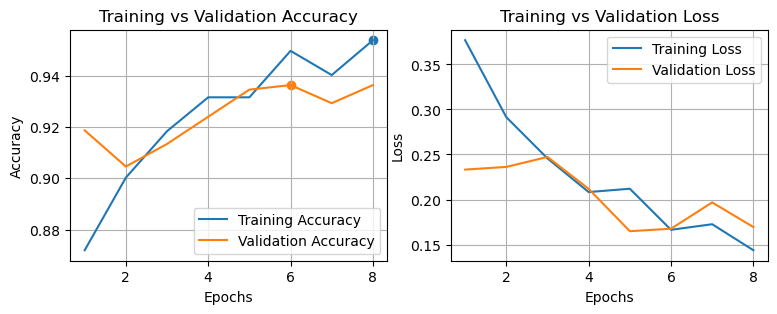

Best Training Accuracy: 0.9539101123809814
Best Validation Accuracy: 0.9363957643508911


In [88]:
import matplotlib.pyplot as plt
import numpy as np


train_acc = history_finetune.history['accuracy']
val_acc = history_finetune.history['val_accuracy']


train_loss = history_finetune.history['loss']
val_loss = history_finetune.history['val_loss']

epochs_range = range(1, len(train_acc) + 1)


best_train_acc = max(train_acc)
best_val_acc = max(val_acc)


plt.figure(figsize=(9, 3))


plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')

plt.scatter(np.argmax(train_acc) + 1, best_train_acc)
plt.scatter(np.argmax(val_acc) + 1, best_val_acc)

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)

plt.show()


print("Best Training Accuracy:", best_train_acc)
print("Best Validation Accuracy:", best_val_acc)

In [71]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR , "test"),
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False,
    label_mode="int"
)

Found 573 files belonging to 5 classes.


In [72]:
test_loss, test_acc = model.evaluate(test_ds)
print("Final Test Accuracy:", test_acc)


18/18 [==============================] - 16s 866ms/step - loss: 0.2063 - accuracy: 0.9284
Final Test Accuracy: 0.9284467697143555


In [73]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 [==============================] - 2s 2s/step
Classification Report:
                precision    recall  f1-score   support

   Anthracnose       0.68      0.87      0.76        52
     Black Pox       0.97      0.96      0.96        71
     Black Rot       0.88      0.79      0.83       103
       Healthy       0.97      0.99      0.98       268
Powdery Mildew       1.00      0.94      0.97        79

      accuracy                           0.93       573
     macro avg       0.90      0.91      0.90       573
  weighted avg       0.93      0.93      0.93       573

Confusion Matrix:
[[ 45   0   7   0   0]
 [  1  68   1   1   0]
 [ 20   1  81   1   0]
 [  0   1   3 264   0]
 [  0   0   0   5  74]]


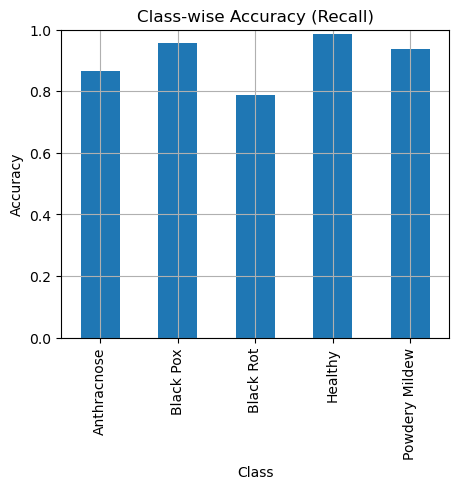

In [77]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
df = pd.DataFrame(report).transpose()

plt.figure(figsize=(5,4))
df['recall'][:-3].plot(kind='bar')
plt.title("Class-wise Accuracy (Recall)")
plt.ylabel("Accuracy")
plt.xlabel("Class")
plt.ylim(0, 1)
plt.grid(True)
plt.show()

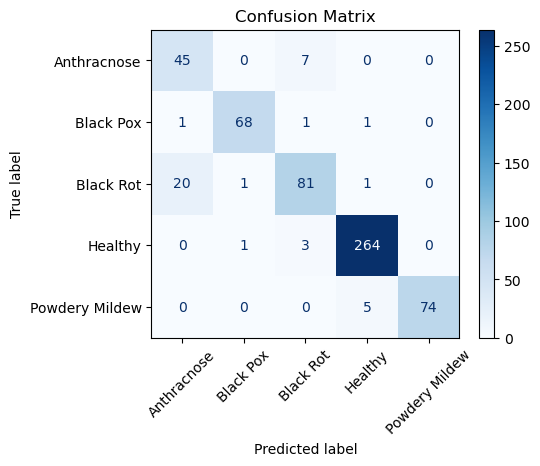

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
class_names = test_ds.class_names
cm = confusion_matrix(y_true, y_pred)
fig, ax=plt.subplots(figsize=(5,4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(ax=ax,cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [90]:
model.save("apple_mobilenet_project.h5")